# Raman BLL Spectra and PC-LDA Analysis

This notebook reproduces the main analyses from `Raman_B_basic_spectra.ipynb` and `raman_pclda.ipynb` on `./data/Raman_B_ALL_preB.h5ad`.

For figure readability, the original label `ALL-preB` is renamed to `BLL` during analysis and plotting.


In [1]:
# Role: Imports, editable figure settings, and output directory setup.
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import matplotlib as mpl
from pathlib import Path
from scipy import sparse
from matplotlib import colors as mcolors
from sklearn.preprocessing import MinMaxScaler, StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc

plt.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 12
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'

sns.set_context('notebook')
sns.set_style('whitegrid')

OUTPUT_DIR = Path('./results/figure5')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('output_dir:', OUTPUT_DIR.resolve())


output_dir: /data/liulab/chenming/research/Raman2SC/transfer_data_20260303/results/figure5


In [2]:
# Role: Load Raman data and rename ALL-preB to BLL for downstream analysis.
raman_adata = sc.read_h5ad('./data/Raman_B_ALL_preB.h5ad')
raman_adata = raman_adata.copy()
raman_adata.obs['cell_type'] = raman_adata.obs['cell_type'].astype(str).replace({'ALL-preB': 'BLL'})
raman_adata


AnnData object with n_obs × n_vars = 1957 × 432
    obs: 'cell_type'
    var: 'mean', 'std'
    uns: 'cell_type_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'norm', 'raw'
    obsp: 'connectivities', 'distances'

In [3]:
# Role: Validate and use the existing raw and normalized layers from the AnnData object.
adata_work = raman_adata.copy()
if 'raw' not in adata_work.layers or 'norm' not in adata_work.layers:
    raise KeyError("This dataset is expected to contain both layers['raw'] and layers['norm'].")

# Keep the original X unchanged and build an additional scaled layer only from the normalized matrix.
adata_norm_for_scale = adata_work.copy()
adata_norm_for_scale.X = np.asarray(adata_work.layers['norm']) if not sparse.issparse(adata_work.layers['norm']) else adata_work.layers['norm'].toarray()
sc.pp.scale(adata_norm_for_scale)
adata_work.layers['scaled_from_norm'] = adata_norm_for_scale.X.copy()

print(adata_work)


AnnData object with n_obs × n_vars = 1957 × 432
    obs: 'cell_type'
    var: 'mean', 'std'
    uns: 'cell_type_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'norm', 'raw', 'scaled_from_norm'
    obsp: 'connectivities', 'distances'


In [4]:
# Role: Helper functions for matrix extraction, wavenumber handling, and figure export.
def save_figure(fig, name, dpi=300, show=True):
    for ext in ['png', 'pdf', 'svg']:
        fig.savefig(OUTPUT_DIR / f'{name}.{ext}', dpi=dpi, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)


def _to_dense(X):
    if sparse.issparse(X):
        return X.toarray()
    return np.asarray(X)


def _get_layer_matrix(adata, layer=None):
    X = adata.X if layer is None else adata.layers[layer]
    return _to_dense(X)


def _get_wavenumbers(adata):
    w = pd.to_numeric(pd.Index(adata.var_names), errors='coerce')
    if w.isna().any():
        raise ValueError('Some var_names are not numeric wavenumbers.')
    return w


def _subset_wavenumber_range(adata, wn_min=600, wn_max=1800):
    w = _get_wavenumbers(adata)
    mask = (w >= wn_min) & (w <= wn_max)
    return mask, w[mask]


def build_spectra_df(adata, layer=None, wn_min=600, wn_max=1800):
    mask, w_subset = _subset_wavenumber_range(adata, wn_min, wn_max)
    X = _get_layer_matrix(adata, layer=layer)[:, mask]
    df = pd.DataFrame(X, columns=w_subset)
    df['cell_type'] = adata.obs['cell_type'].astype(str).values
    df = pd.melt(df, id_vars='cell_type', var_name='Wavenumber', value_name='Intensity')
    df['Wavenumber'] = pd.to_numeric(df['Wavenumber'], errors='coerce')
    return df


In [5]:
# Role: Define class order, colors, and highlighted Raman peak regions.
ORDER = ['HSC', 'Pro B', 'Pre B', 'Naive B', 'BLL']
class_color_map = {
    'HSC': '#1f77b4',
    'Pro B': '#17becf',
    'Pre B': '#2ca02c',
    'Naive B': '#d62728',
    'BLL': '#9467bd',
}
classes = np.array([c for c in ORDER if c in adata_work.obs['cell_type'].astype(str).unique()])
adata_work.obs['cell_type'] = pd.Categorical(adata_work.obs['cell_type'], categories=classes, ordered=True)
adata_work.uns['cell_type_colors'] = [class_color_map[c] for c in classes]
highlight_ranges = [(950, 1000), (1400, 1700)]
print(adata_work.obs['cell_type'].value_counts())


cell_type
BLL        542
Pro B      431
Pre B      330
HSC        329
Naive B    325
Name: count, dtype: int64


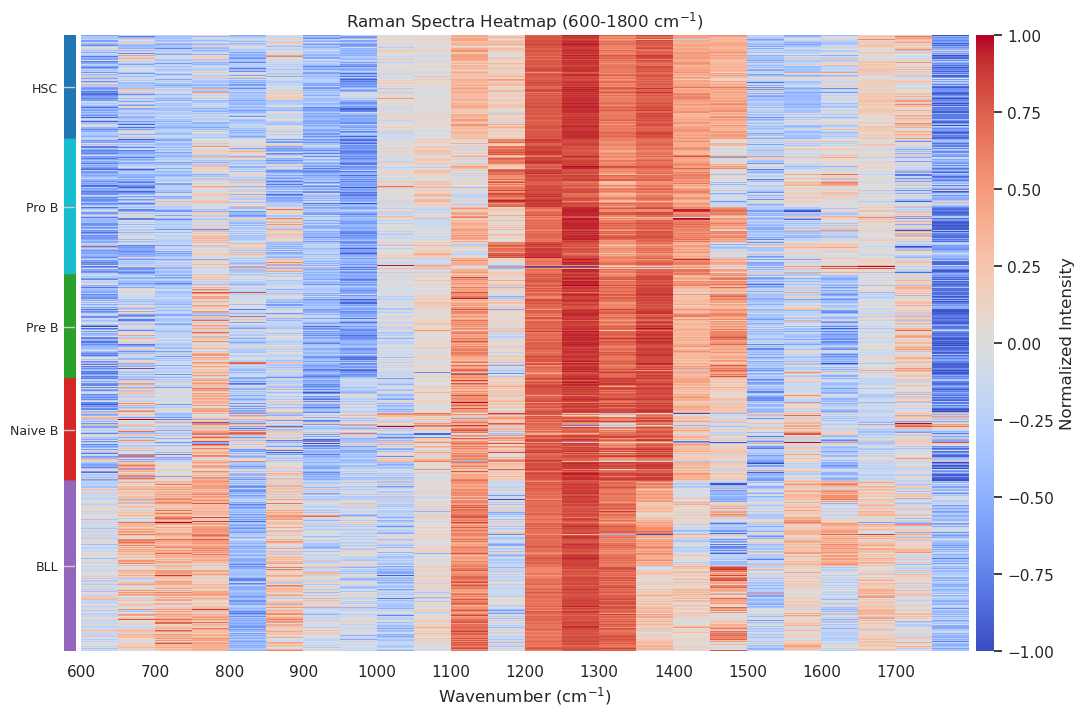

In [6]:
# Role: Heatmap of normalized Raman spectra across all cells, matching the original visualization style.
mask, w_subset = _subset_wavenumber_range(adata_work, 600, 1800)
X = _get_layer_matrix(adata_work, layer='norm' if 'norm' in adata_work.layers else None)
X = X[:, mask]

# Bin every 50 cm^-1 by averaging columns
bin_size = 50
bins = (w_subset.values // bin_size) * bin_size
unique_bins = np.sort(np.unique(bins))
X_binned = np.zeros((X.shape[0], len(unique_bins)))
for i, b in enumerate(unique_bins):
    X_binned[:, i] = X[:, bins == b].mean(axis=1)

# Normalize to [-1, 1] per binned wavenumber
scaler = MinMaxScaler(feature_range=(-1, 1))
X_norm = scaler.fit_transform(X_binned)

# Order cells by cell_type
cell_type = adata_work.obs['cell_type'].astype(str).values
order = np.argsort(pd.Categorical(cell_type, categories=classes, ordered=True).codes)
X_plot = X_norm[order, :]
cell_type_sorted = cell_type[order]

# Row color strip for cell types (RGBA)
row_colors = np.array([mcolors.to_rgba(class_color_map[ct]) for ct in cell_type_sorted])

fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(1, 3, width_ratios=[0.012, 0.968, 0.02], wspace=0.02)
ax_color = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

ax_color.imshow(row_colors.reshape(-1, 1, 4), aspect='auto')
ax_color.set_xticks([])
ax_color.set_yticks([])
for spine in ax_color.spines.values():
    spine.set_visible(False)

sns.heatmap(X_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar=True, cbar_ax=cax,
            cbar_kws={'label': 'Normalized Intensity'},
            xticklabels=False, yticklabels=False, ax=ax)
ax.set_title('Raman Spectra Heatmap (600-1800 cm$^{-1}$)')
ax.set_xlabel('Wavenumber (cm$^{-1}$)')
ax.set_ylabel('')

tick_bins = [int(b) for b in unique_bins if b % 100 == 0]
tick_idx = [np.where(unique_bins == b)[0][0] for b in tick_bins]
ax.set_xticks(tick_idx)
ax.set_xticklabels(tick_bins, rotation=0)

group_bounds = []
start = 0
for ct in classes:
    count = np.sum(cell_type_sorted == ct)
    end = start + count
    group_bounds.append((ct, start, end))
    start = end

ax_color.set_yticks([(s + e) / 2 for (_, s, e) in group_bounds])
ax_color.set_yticklabels([ct for (ct, _, __) in group_bounds], fontsize=9)
ax_color.yaxis.set_ticks_position('left')
ax_color.tick_params(axis='y', length=0, pad=4)

save_figure(fig, 'raman_bll_heatmap')


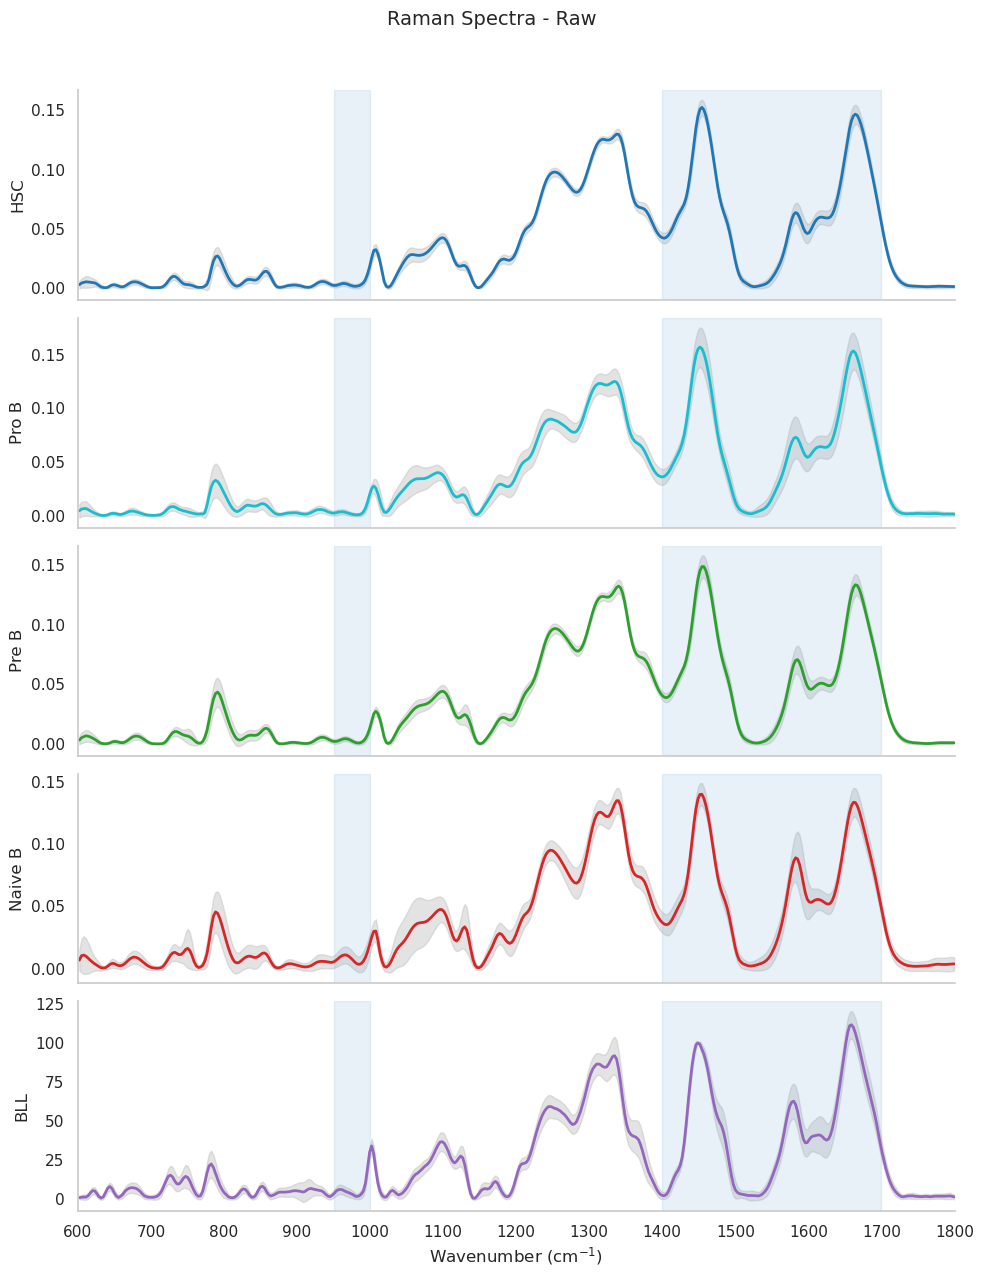

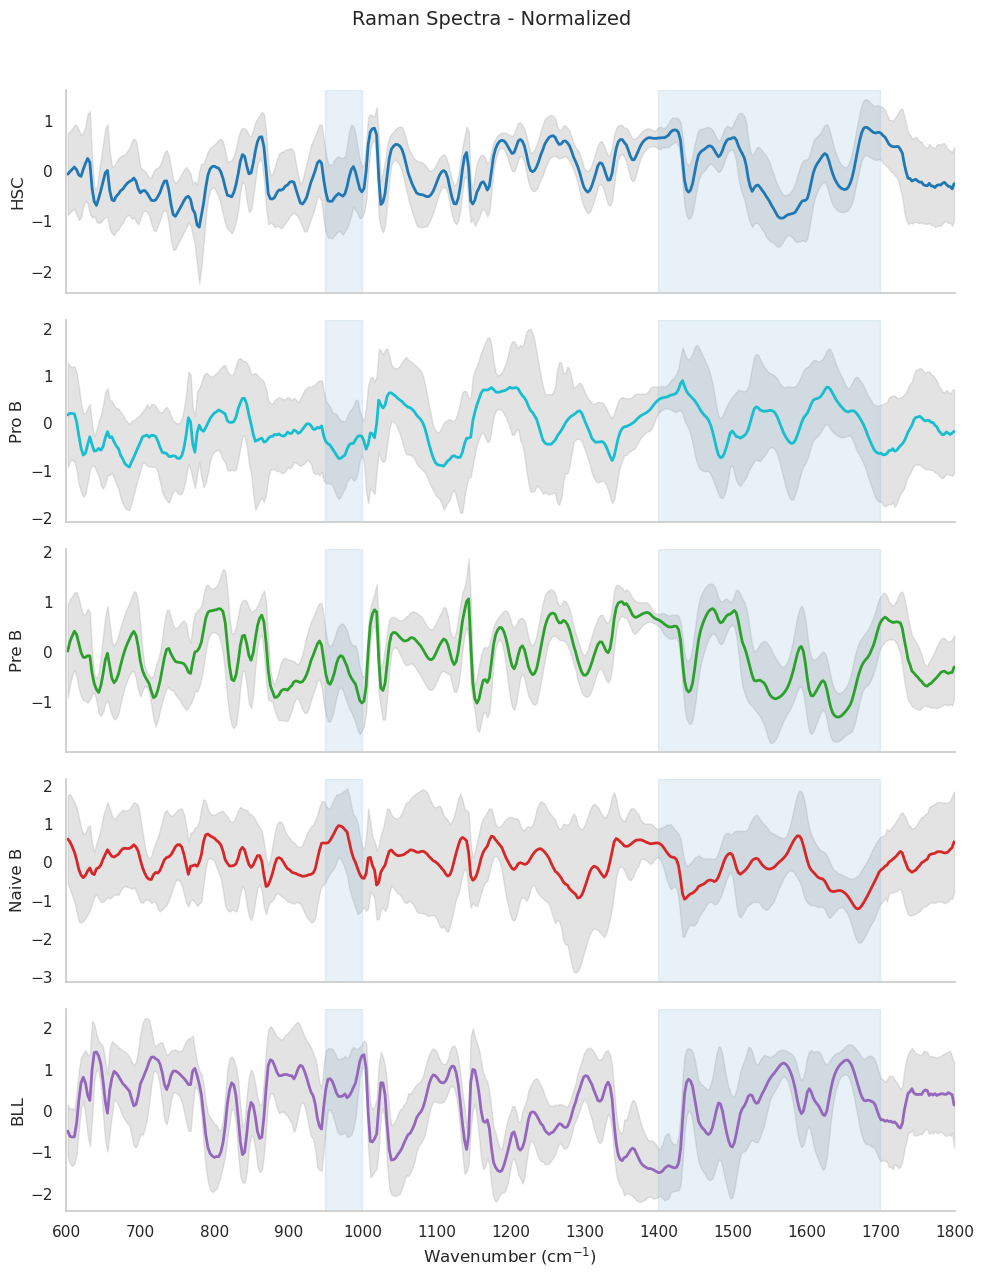

In [7]:
# Role: Plot mean Raman spectra with standard deviation bands for each cell type.
def plot_facet_spectra_summary(df, title, highlight_ranges=None, fname='spectra_summary'):
    agg = df.groupby(['cell_type', 'Wavenumber']).agg(
        mean_intensity=('Intensity', 'mean'),
        std_intensity=('Intensity', 'std')
    ).reset_index()
    cell_types = [ct for ct in classes if ct in agg['cell_type'].unique()]

    fig, axes = plt.subplots(nrows=len(cell_types), ncols=1, figsize=(10, 2.5 * len(cell_types)), sharex=True)
    if len(cell_types) == 1:
        axes = [axes]

    for ax, ct in zip(axes, cell_types):
        sub = agg[agg['cell_type'] == ct]
        ax.plot(sub['Wavenumber'], sub['mean_intensity'], color=class_color_map[ct], linewidth=2.0)
        ax.fill_between(
            sub['Wavenumber'],
            sub['mean_intensity'] - sub['std_intensity'],
            sub['mean_intensity'] + sub['std_intensity'],
            color='#B0B0B0', alpha=0.35,
        )
        if highlight_ranges:
            for start, end in highlight_ranges:
                ax.axvspan(start, end, color='#7FB3D5', alpha=0.18)
        ax.set_ylabel(ct)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(False)

    axes[-1].set_xlabel('Wavenumber (cm$^{-1}$)')
    axes[-1].set_xlim(600, 1800)
    axes[-1].set_xticks(np.arange(600, 1801, 100))
    fig.suptitle(title, y=1.02, fontsize=14)
    fig.tight_layout()
    save_figure(fig, fname)


df_raw = build_spectra_df(adata_work, layer='raw', wn_min=600, wn_max=1800)
df_norm = build_spectra_df(adata_work, layer='norm', wn_min=600, wn_max=1800)
plot_facet_spectra_summary(df_raw, 'Raman Spectra - Raw', highlight_ranges=highlight_ranges, fname='raman_bll_raw_spectra')
plot_facet_spectra_summary(df_norm, 'Raman Spectra - Normalized', highlight_ranges=highlight_ranges, fname='raman_bll_normalized_spectra')


In [8]:
# Role: PC-LDA training and train/test evaluation.
def _get_dense_X(adata):
    X = adata.X
    if sparse.issparse(X):
        X = X.toarray()
    return np.asarray(X)


def pclda_train_test(adata, group='cell_type', percent=98, test_size=0.2, random_state=42, scale=True):
    X = _get_dense_X(adata)
    y = adata.obs[group].astype(str).values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    scaler = None
    if scale:
        scaler = StandardScaler(with_mean=True)
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    pca = PCA()
    X_train_pca = pca.fit_transform(X_train)
    cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
    n_pcs = np.searchsorted(cum_var, percent) + 1

    X_train_pca = X_train_pca[:, :n_pcs]
    X_test_pca = pca.transform(X_test)[:, :n_pcs]

    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train_pca, y_train)

    X_train_lda = lda.transform(X_train_pca)
    X_test_lda = lda.transform(X_test_pca)
    y_pred = lda.predict(X_test_pca)
    y_proba = lda.predict_proba(X_test_pca)
    acc = accuracy_score(y_test, y_pred)

    n_lda = X_train_lda.shape[1]
    cols = [f'LDA_{i+1}' for i in range(n_lda)]
    U_train = pd.DataFrame(X_train_lda, columns=cols)
    U_train['group'] = y_train
    U_train['split'] = 'Train'
    U_test = pd.DataFrame(X_test_lda, columns=cols)
    U_test['group'] = y_test
    U_test['split'] = 'Test'

    return {
        'U_train': U_train,
        'U_test': U_test,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'classes': lda.classes_,
        'acc': acc,
        'n_pcs': n_pcs,
    }

res = pclda_train_test(raman_adata, group='cell_type', percent=98, test_size=0.2, random_state=42, scale=True)
print(f'PCs retained: {res["n_pcs"]}')
print(f'Test accuracy: {res["acc"]:.4f}')


PCs retained: 156
Test accuracy: 0.9719


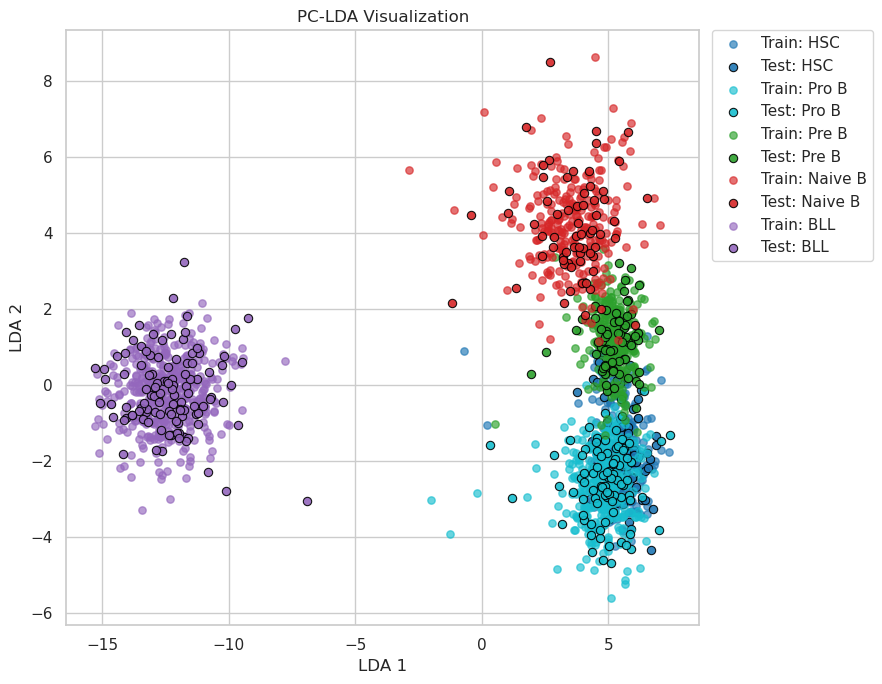

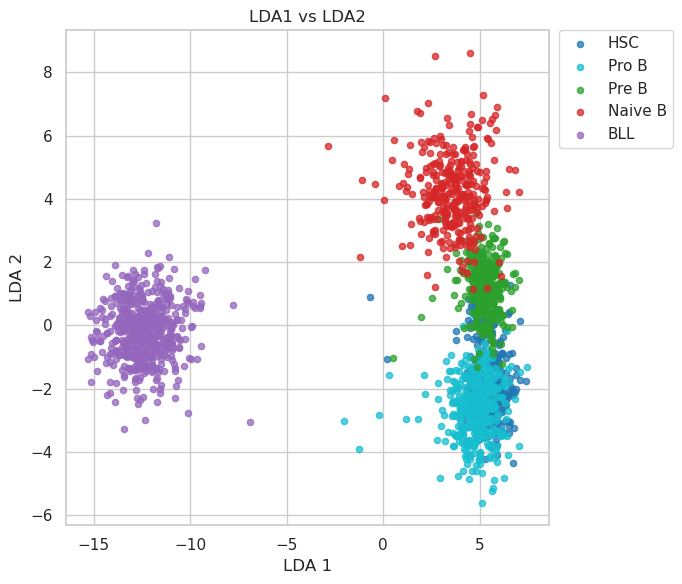

In [9]:
# Role: Plot PC-LDA train/test scatter and class-only scatter.
U_train = res['U_train']
U_test = res['U_test']
U_all = pd.concat([U_train, U_test], axis=0, ignore_index=True)
plot_classes = [c for c in classes if c in set(U_all['group'])]

fig, ax = plt.subplots(figsize=(9, 7))
for group in plot_classes:
    g_train = U_train[U_train['group'] == group]
    g_test = U_test[U_test['group'] == group]
    color = class_color_map[group]
    ax.scatter(g_train['LDA_1'], g_train['LDA_2'], label=f'Train: {group}', color=color, alpha=0.65, s=28)
    ax.scatter(g_test['LDA_1'], g_test['LDA_2'], label=f'Test: {group}', color=color, edgecolor='k', alpha=0.9, linewidth=0.8, s=36)
ax.set_xlabel('LDA 1')
ax.set_ylabel('LDA 2')
ax.set_title('PC-LDA Visualization')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
fig.tight_layout()
save_figure(fig, 'pclda_train_test')

fig, ax = plt.subplots(figsize=(7, 6))
for group in plot_classes:
    data = U_all[U_all['group'] == group]
    ax.scatter(data['LDA_1'], data['LDA_2'], s=20, alpha=0.75, color=class_color_map[group], label=group)
ax.set_xlabel('LDA 1')
ax.set_ylabel('LDA 2')
ax.set_title('LDA1 vs LDA2')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
fig.tight_layout()
save_figure(fig, 'lda1_lda2_all')


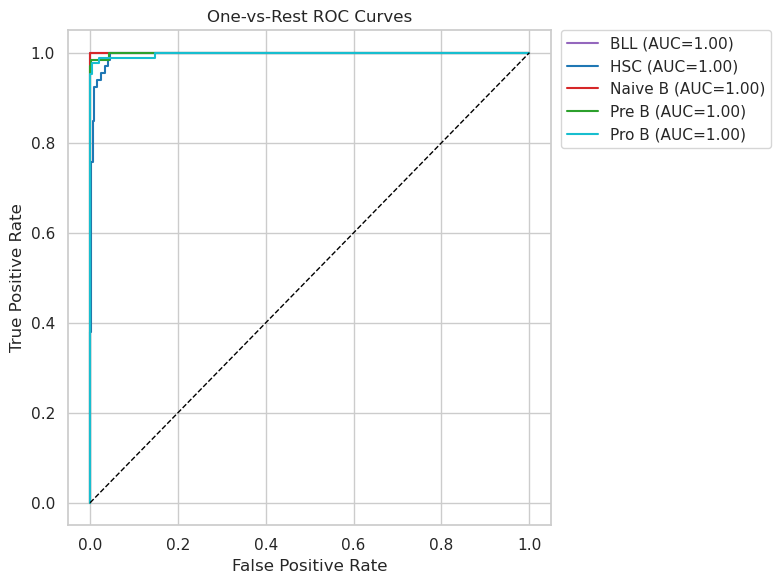

Single split confusion table:
Predicted  BLL  HSC  Naive B  Pre B  Pro B
Actual                                    
BLL        109    0        0      0      0
HSC          0   62        0      4      0
Naive B      0    1       64      0      0
Pre B        0    1        0     65      0
Pro B        0    5        0      0     81
Single split accuracy: 0.9719
Repeated split accuracy summary:
   seed       acc
0     0  0.979592
1     1  0.964286
2     2  0.969388
3     3  0.974490
4     4  0.977041
5     5  0.971939
6     6  0.964286
7     7  0.964286
8     8  0.964286
9     9  0.966837
Mean accuracy: 0.9696428571428571
Std accuracy: 0.005823433220497931


In [10]:
# Role: Plot one-vs-rest ROC curves, confusion summary, and repeated split robustness for PC-LDA.
fig, ax = plt.subplots(figsize=(8, 6))
y_bin = label_binarize(res['y_test'], classes=res['classes'])
for i, cls in enumerate(res['classes']):
    fpr, tpr, _ = roc_curve(y_bin[:, i], res['y_proba'][:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{cls} (AUC={roc_auc:.2f})', color=class_color_map.get(cls, None))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('One-vs-Rest ROC Curves')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
fig.tight_layout()
save_figure(fig, 'pclda_roc')

conf_table = pd.crosstab(pd.Series(res['y_test'], name='Actual'), pd.Series(res['y_pred'], name='Predicted'))
conf_table = conf_table.reindex(index=res['classes'], columns=res['classes'], fill_value=0)
print('Single split confusion table:')
print(conf_table)
print(f'Single split accuracy: {res["acc"]:.4f}')

repeat_rows = []
for seed in range(10):
    res_seed = pclda_train_test(raman_adata, group='cell_type', percent=98, test_size=0.2, random_state=seed, scale=True)
    repeat_rows.append({'seed': seed, 'acc': res_seed['acc']})
repeat_df = pd.DataFrame(repeat_rows)
print('Repeated split accuracy summary:')
print(repeat_df)
print('Mean accuracy:', repeat_df['acc'].mean())
print('Std accuracy:', repeat_df['acc'].std())


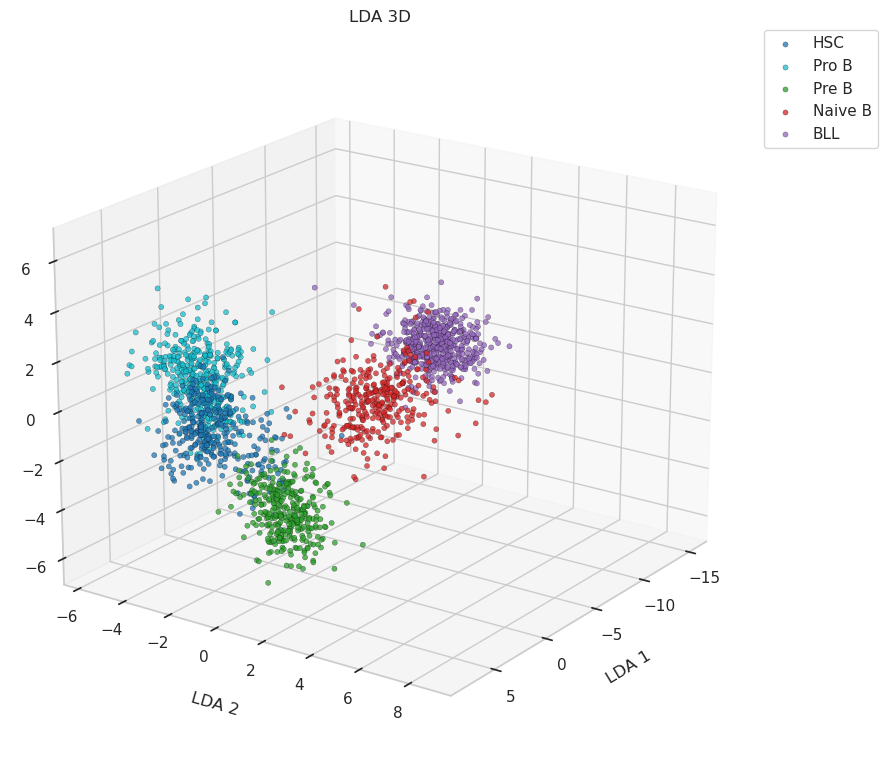

In [11]:
# Role: Plot 3D LDA visualization following the original PC-LDA notebook style.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

if {'LDA_1', 'LDA_2', 'LDA_3'}.issubset(U_all.columns):
    fig = plt.figure(figsize=(15.8, 8.8))
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=20, azim=35)
    ax.set_box_aspect((1, 1, 0.8))
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)

    for cls in plot_classes:
        data = U_all[U_all['group'] == cls]
        ax.scatter(
            data['LDA_1'], data['LDA_2'], data['LDA_3'],
            s=14, alpha=0.75, color=class_color_map[cls],
            label=cls, edgecolor='k', linewidth=0.2
        )

    ax.set_xlabel('LDA 1', labelpad=10)
    ax.set_ylabel('LDA 2', labelpad=14)
    ax.set_zlabel('LDA 3', labelpad=12)
    ax.xaxis.set_label_coords(0.85, -0.05)
    ax.yaxis.set_label_coords(-0.05, 0.2)
    ax.zaxis.set_label_coords(-0.08, 0.5)
    ax.set_title('LDA 3D')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    fig.subplots_adjust(left=0.10, right=0.82, top=0.92, bottom=0.08)
    save_figure(fig, 'lda_3d')
else:
    print('Skipping 3D LDA plot because fewer than 3 LDA components are available.')
